In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

In [3]:
file_path = "CS-IDX30 version 3/CS-IDX30 version 3/CS-IDX30 version 3/pricehistory data/Finance/BBCA.JK_dataprice.xlsx"

df_raw = pd.read_excel(file_path)
df_raw['Date'] = pd.to_datetime(df_raw['Date'])
df_raw = df_raw.sort_values('Date').reset_index(drop=True)

# Use OHLCV (optional) + Close as target
df = df_raw[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']].copy()
df.rename(columns={'Date': 'ds', 'Close': 'y'}, inplace=True)

# Ensure numeric and handle missing values
for col in ['Open', 'High', 'Low', 'y', 'Volume']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df[['Open','High','Low','y','Volume']] = df[['Open','High','Low','y','Volume']].interpolate(method='linear')
df[['Open','High','Low','y','Volume']] = df[['Open','High','Low','y','Volume']].ffill().bfill()


In [4]:
# Feature Engineering

df['ret_1'] = df['y'].pct_change()

# Lags of price and return
for lag in [1, 2, 3, 5, 10, 20, 30]:
    df[f'lag_{lag}'] = df['y'].shift(lag)
    df[f'ret_lag_{lag}'] = df['ret_1'].shift(lag)

# Rolling indicators (moving averages + volatility)
for w in [5, 10, 20, 30]:
    df[f'ma_{w}'] = df['y'].rolling(w).mean()
    df[f'std_{w}'] = df['y'].rolling(w).std()

# Volume-based rolling
for w in [5, 10, 20]:
    df[f'vol_ma_{w}'] = df['Volume'].rolling(w).mean()

# Calendar features
df['dow'] = df['ds'].dt.dayofweek
df['month'] = df['ds'].dt.month

# Target: next-day close (shift -1)
df['y_next'] = df['y'].shift(-1)

# Drop rows created by shifting/rolling
df_feat = df.dropna().copy()


In [6]:
# 4. Train-test split (last 120 days as test)

TEST_SIZE = 120
train_df = df_feat.iloc[:-TEST_SIZE].copy()
test_df  = df_feat.iloc[-TEST_SIZE:].copy()

# Features and target
feature_cols = [c for c in df_feat.columns if c not in ['ds', 'y', 'y_next']]
X_train = train_df[feature_cols]
y_train = train_df['y_next']   # next-day target

X_test  = test_df[feature_cols]
y_true  = test_df['y_next']    # actual next-day close for those dates

test_dates = test_df['ds'].values 

In [7]:
model = XGBRegressor(
    n_estimators=600,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.0,
    reg_lambda=1.0,
    objective='reg:squarederror',
    random_state=42,
)

model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# ================================
# 6. Metrics: MAE, RMSE + %
# ================================
MAE  = mean_absolute_error(y_true, y_pred)
RMSE = np.sqrt(mean_squared_error(y_true, y_pred))
mean_price = np.mean(y_true)

MAE_percent  = (MAE / mean_price) * 100
RMSE_percent = (RMSE / mean_price) * 100

print("\n===== XGBoost Performance Metrics (Next-Day Forecast, Last 120 Days) =====")
print(f"MAE  : {MAE:,.2f}   ({MAE_percent:.2f}%)")
print(f"RMSE : {RMSE:,.2f}   ({RMSE_percent:.2f}%)")


===== XGBoost Performance Metrics (Next-Day Forecast, Last 120 Days) =====
MAE  : 188.52   (2.48%)
RMSE : 244.08   (3.21%)


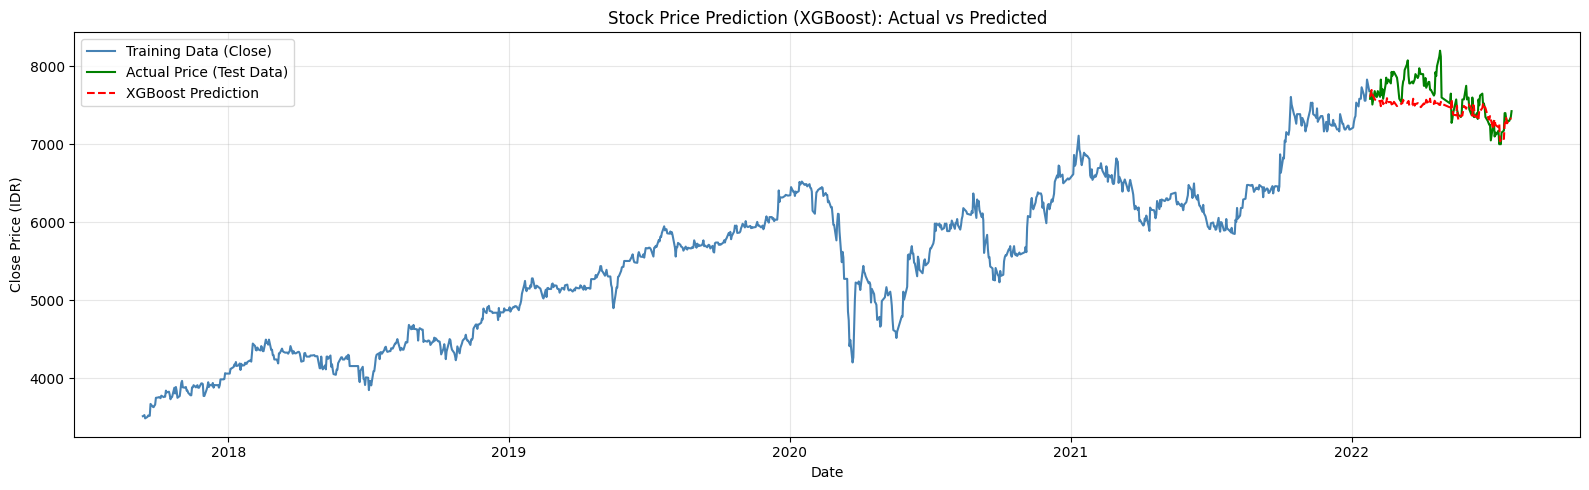

In [8]:
# 7. Plot Prep

train_actual = df_feat.iloc[:-TEST_SIZE][['ds','y']].copy()

plot_test = pd.DataFrame({
    'ds': test_dates,
    'actual_next': y_true.values,
    'pred_next': y_pred
})

# ================================
# 8. Plot – full history
# ================================
plt.figure(figsize=(16, 5))

plt.plot(train_actual['ds'], train_actual['y'],
         label='Training Data (Close)', color='steelblue')

plt.plot(plot_test['ds'], plot_test['actual_next'],
         label='Actual Price (Test Data)', color='green')

plt.plot(plot_test['ds'], plot_test['pred_next'],
         'r--', label='XGBoost Prediction')

plt.title('Stock Price Prediction (XGBoost): Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Close Price (IDR)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

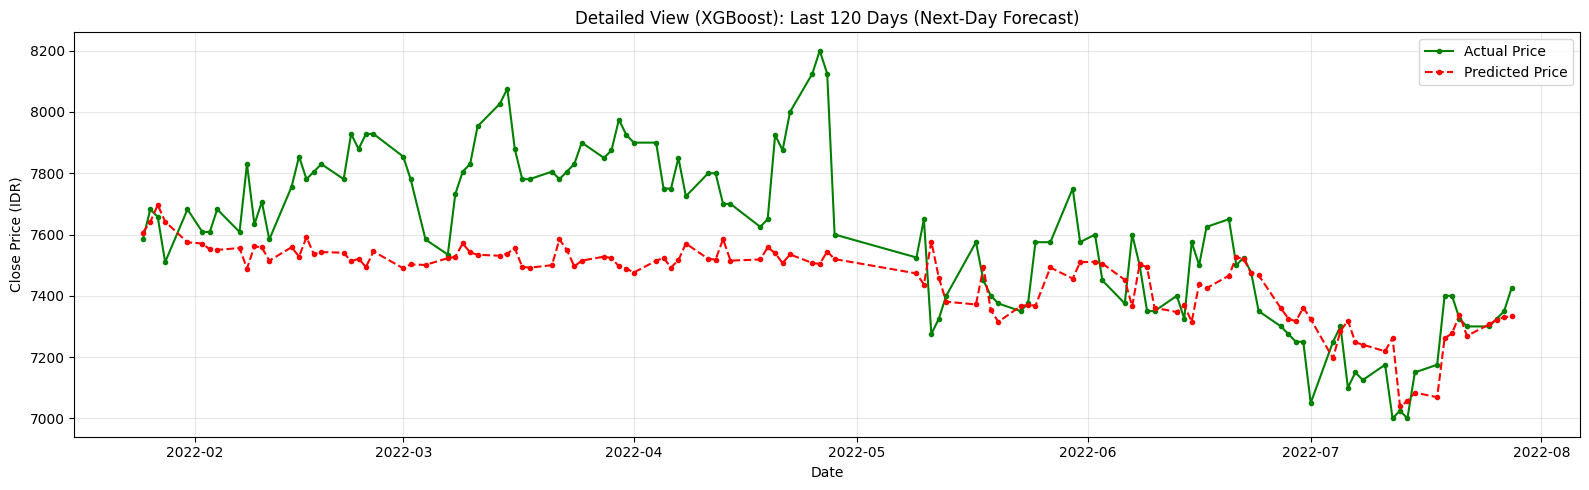

In [9]:
plt.figure(figsize=(16, 5))

plt.plot(plot_test['ds'], plot_test['actual_next'],
         'g.-', label='Actual Price')
plt.plot(plot_test['ds'], plot_test['pred_next'],
         'r.--', label='Predicted Price')

plt.title('Detailed View (XGBoost): Last 120 Days (Next-Day Forecast)')
plt.xlabel('Date')
plt.ylabel('Close Price (IDR)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()